In [1]:
import json
import matplotlib.pyplot as plt
import numpy as np

In [30]:
def running_mean(x, N):
    cumsum = np.cumsum(np.insert(x, 0, 0)) 
    return (cumsum[N:] - cumsum[:-N]) / float(N)

with open("./4class_best.json", "r") as f:
    data = json.load(f)


models = ['quantum', 'classical']
privacy = ['private', 'nonprivate']

color_map = {
    "privateclassical": "#ff7f0e",
    "privatequantum":   "#d62728",
    "nonprivateclassical": "#1f77b4",
    "nonprivatequantum": "#2ca02c",
    "classical": "#ff7f0e",
    "quantum":   "#d62728",
}

plt.rcParams['text.usetex'] = False
rm = 2

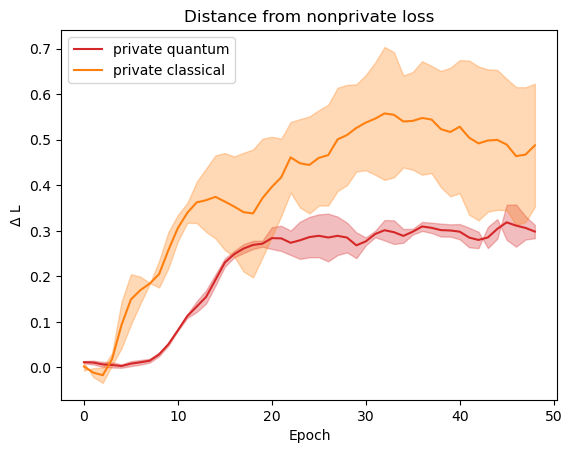

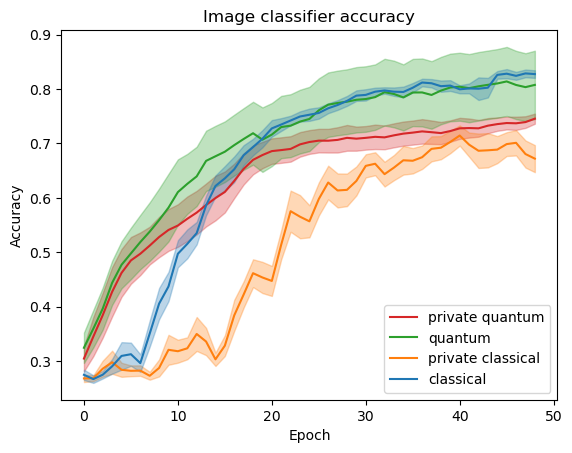

In [31]:
for m in models:
    mean = np.mean(data[m]['private']['tr'], axis = 0) - np.mean(data[m]['nonprivate']['tr'], axis = 0)
    std = np.std(np.array(data[m]['private']['tr']), axis = 0) - np.std(np.array(data[m]['nonprivate']['tr']), axis = 0)

    plt.plot(running_mean(mean, rm), label = f"private {m}", color = color_map[m])
    plt.fill_between(range(len(running_mean(mean, rm))), running_mean(mean - std, rm), running_mean(mean + std, rm), alpha = 0.3, color = color_map[m])

plt.title('Distance from nonprivate loss')
plt.ylabel('Δ L')
plt.xlabel('Epoch')

plt.legend()
plt.show()



for m in models:
	for p in privacy:
		mean = np.mean(data[m][p]['tst_accs'], axis = 0)
		std = np.std(np.array(data[m][p]['tst_accs']), axis = 0) / 3

		plt.plot(running_mean(mean, rm), label = f"{f'{p} ' if p == "private" else ""}{m}", color = color_map[f"{p}{m}"])
		plt.fill_between(range(len(running_mean(mean, rm))), running_mean(mean - std, rm), running_mean(mean + std , rm), alpha = 0.3, color = color_map[f"{p}{m}"])

plt.title('Image classifier accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()
plt.show()